<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
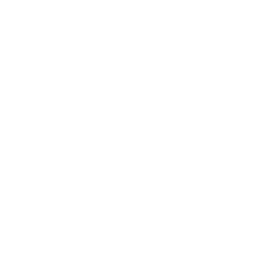
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">EWMA-trendanalyse for Medicineringsfejlrate</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Sundhedsvæsen / Patientsikkerhed &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Resumé

Denne analyse overvåger den ugentlige medicineringsfejlrate på en intensivafdeling (ICU) ved hjælp af et **eksponentielt vægtet glidende gennemsnit (EWMA) kontroldiagram** fra PROC MACONTROL. Intensivafdelingen udrullede et nyt elektronisk medicineringsjournalsystem (eMAR) i uge 51 af observationsperioden. Patientsikkerhedsteams har brug for en tidlig-advarselsmetode, der hurtigt flager en vedvarende stigning i fejl, før en fjerdedel af skadesrapporterne akkumuleres.

EWMA-diagrammet med udjævningsvægt **lambda = 0,3** opbygges i to faser. Kontrolgrænser etableres først ud fra den stabile baseline før migrering (uge 1-50), hvorefter hele 100-ugers-serien overvåges mod disse faste grænser. Diagrammet forbliver i kontrol gennem hele baselineperioden og signalerer en ude-af-kontrol-tilstand **den første uge efter idriftsættelse**, hvilket bekræfter, at eMAR-overgangen faldt sammen med et reelt, vedvarende skift i fejlraten frem for almindelig uge-til-uge-støj.

## Datakilder

| Kilde | Beskrivelse | Observationer |
|--------|-------------|---------|
| WORK.ICU_ERRORS | Ugentlig medicineringsfejlrate pr. 1.000 administrationer for én intensivafdeling, 100 sammenhængende uger | 100 |

Én intensivafdeling spores ugentligt. Hver observation indeholder ugenummeret, fejlraten pr. 1.000 administrationer, administrationsvolumen og det afledte fejlantal. En dokumenteret procesændring (eMAR-idriftsættelse) sker i uge 51 og hæver den underliggende gennemsnitlige fejlrate med ca. 1,6 pr. 1.000.

---

In [1]:
/* --------------------------------------------------------
   Generer ugentlige medicineringsfejldata for intensivafdeling
   100 sammenhængende uger for én intensivafdeling.
   Et nyt eMAR-system idriftsættes i uge 51, hvilket hæver
   den underliggende gennemsnitlige fejlrate fra ~3,5 til ~5,1 pr. 1.000.
   -------------------------------------------------------- */
data work.icu_errors;
    CALL streaminit(42);
    LÆNGDE unit_name $12 phase $12;
    unit_name = 'ICU';
    base_rate  = 3.5;   /* gennemsnitlig rate før migrering / 1.000 */
    unit_sigma = 0.45;  /* uge-til-uge normal-variation støj */
    GØR week_num = 1 TIL 100;
        week_start_date = '01JAN2024'd + (week_num - 1) * 7;
        administrations = int(rand('normal', 800, 80));
        HVIS administrations < 300 SÅ administrations = 300;
        /* eMAR-migrering hæver gennemsnittet efter uge 50 */
        HVIS week_num > 50 SÅ GØR;
            phase = 'EFTER-eMAR';
            error_rate_per_1k =
                round(rand('normal', base_rate + 1.6, unit_sigma), 0.01);
        SLUT;
        ELLERS GØR;
            phase = 'BASISLINJE';
            error_rate_per_1k =
                round(rand('normal', base_rate, unit_sigma), 0.01);
        SLUT;
        HVIS error_rate_per_1k < 0 SÅ error_rate_per_1k = 0;
        error_count = round(administrations * error_rate_per_1k / 1000);
        UDDATA;
    SLUT;
    FJERN base_rate unit_sigma;
    format week_start_date date9.;
KØR;


NOTE: DATA work.icu_errors


NOTE: Wrote work.icu_errors (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                        ICU-fejlrate: Basislinje vs. Efter-eMAR                                         

                                                  The MEANS Procedure

                                Analysis Variable : error_rate_per_1k Fejlrate pr. 1.000

        Fase                N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------------------------------
        BASISLINJE             50           3.50           0.48           2.55           4.71
        EFTER-eMAR             50           5.11           0.44           3.69           5.96
        -------------------------------------------------------------------------------------

                                       Analysis Variable : error_count Antal Fejl

        Fase                N Obs           Mean        Std Dev        Minimum        Maximum
        -------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SGPLOT data=work.icu_errors

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


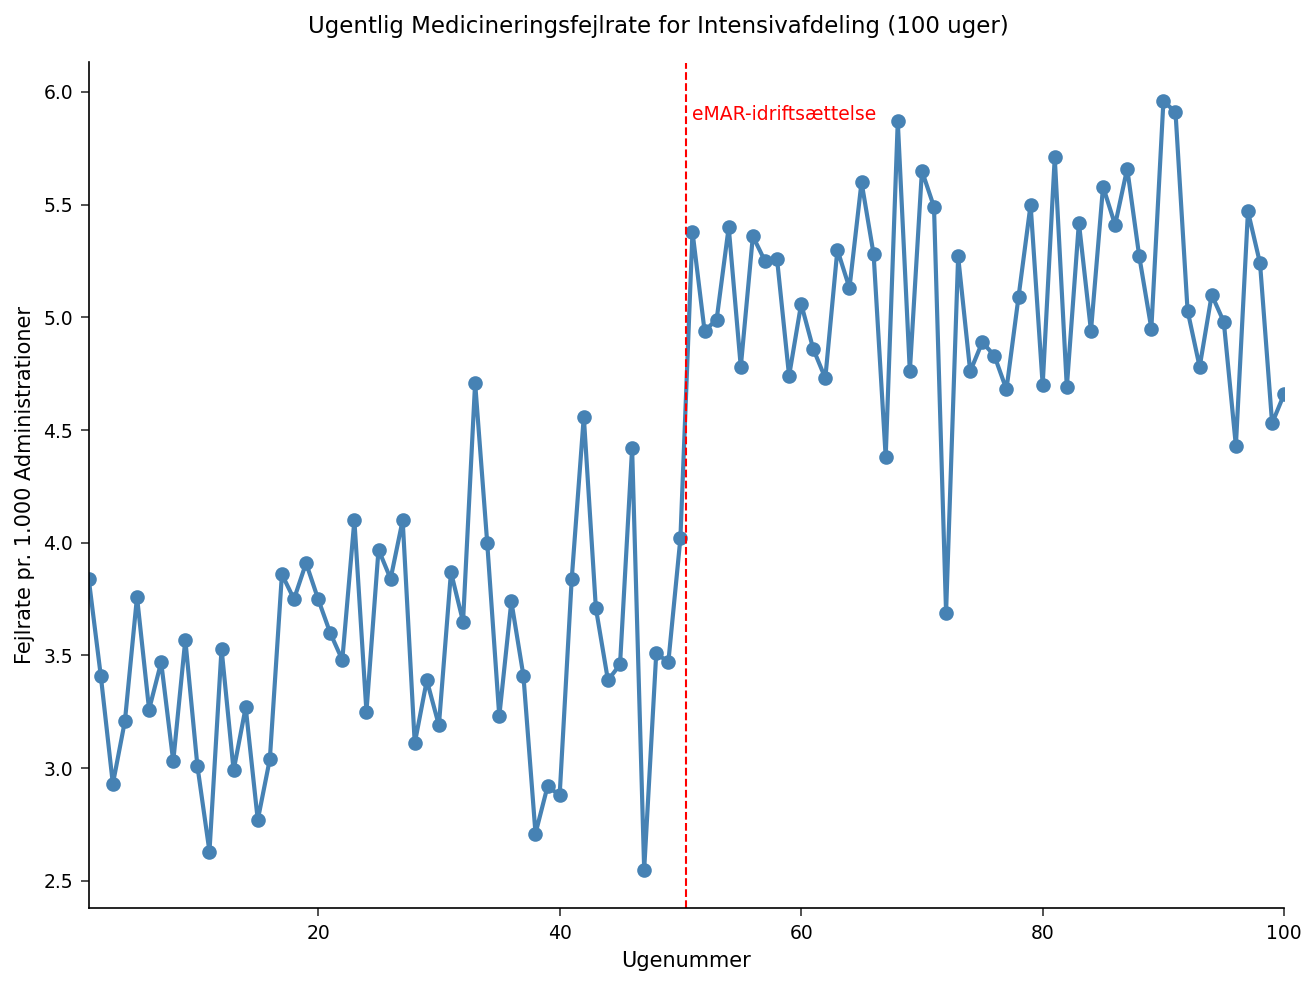

In [2]:
/* --------------------------------------------------------
   Sammenlign fejlraten før og efter eMAR-idriftsættelsen,
   og plot den ugentlige udvikling.
   -------------------------------------------------------- */
PROCEDURE MEANS data=work.icu_errors n mean std MIN MAX maxdec=2;
    KLASSE phase;
    VARIABEL error_rate_per_1k error_count administrations;
    MÆRKAT error_rate_per_1k='Fejlrate pr. 1.000' error_count='Antal Fejl'
          administrations='Administrationer' phase='Fase';
    TITEL 'ICU-fejlrate: Basislinje vs. Efter-eMAR';
KØR;

PROCEDURE SGPLOT data=work.icu_errors;
    SERIES x=week_num y=error_rate_per_1k / MARKERS
           LINEATTRS=(color=steelblue thickness=2);
    REFLINE 50.5 / AXIS=x LINEATTRS=(color=red pattern=dash)
                   MÆRKAT='eMAR-idriftsættelse';
    XAXIS MÆRKAT='Ugenummer';
    YAXIS MÆRKAT='Fejlrate pr. 1.000 Administrationer';
    TITEL 'Ugentlig Medicineringsfejlrate for Intensivafdeling (100 uger)';
KØR;

---

In [3]:
/* --------------------------------------------------------
   Fase I: etabler EWMA-kontrolgrænser fra den stabile
   baseline før migrering (uge 1-50). Disse faste grænser
   bliver målestokken for hele overvågningsperioden.
   -------------------------------------------------------- */
PROCEDURE MEANS data=work.icu_errors(HVOR=(week_num <= 50)) NOPRINT;
    VARIABEL error_rate_per_1k;
    UDDATA out=work.baseline_stats mean=base_mean std=base_std;
KØR;

data work.icu_limits;
    SÆT work.baseline_stats;
    LÆNGDE _VAR_ $32 _SUBGRP_ $32;
    _VAR_    = 'error_rate_per_1k';
    _SUBGRP_ = 'week_num';
    _MEAN_   = base_mean;   /* baseline midterlinje */
    _STDDEV_ = base_std;    /* baseline normal-variation sigma */
    _LIMITN_ = 1;
    BEHOLD _VAR_ _SUBGRP_ _MEAN_ _STDDEV_ _LIMITN_;
KØR;

PROCEDURE PRINT data=work.icu_limits noobs;
    MÆRKAT _VAR_='Variabel' _SUBGRP_='Undergruppe' _MEAN_='Middelværdi'
          _STDDEV_='Std.afv.' _LIMITN_='Grænsenr.';
    TITEL 'Fase I Kontrolgrænse-input (baseline uge 1-50)';
KØR;

                                     Fase I Kontrolgrænse-input (baseline uge 1-50)                                     

         Variabel  Undergruppe   Middelværdi      Std.afv.   Grænsenr.
error_rate_per_1k  week_num           3.5014  0.4829036749           1




NOTE: PROC MEANS
NOTE: Output dataset work.baseline_stats has 1 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.icu_limits


NOTE: Read 1 rows from work.baseline_stats.
NOTE: Wrote work.icu_limits (1 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.icu_limits

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

                                     Fase I Kontrolgrænse-input (baseline uge 1-50)                                     


                    The MACONTROL Procedure
                    EWMA Chart (lambda=0.30)
  Variable:       error_rate_per_1k
  Observations:   100
  Grand Mean:     4.304100
  Sigma:          0.482904
  Sigmas:         3.0
  Average MR:     0.524646
  UCL_MA:         4.769212
  LCL_MA:         3.838988
  UCL_MR:         1.714020





NOTE: PROC MACONTROL
NOTE: Output table written to ./work/5a000d87-fa96-40df-b4dc-b721fe0e504e/icu_table.avro
NOTE: ODS plot written: macontrol_error_rate_per_1k.spec.json
NOTE: PROC MACONTROL statement used.


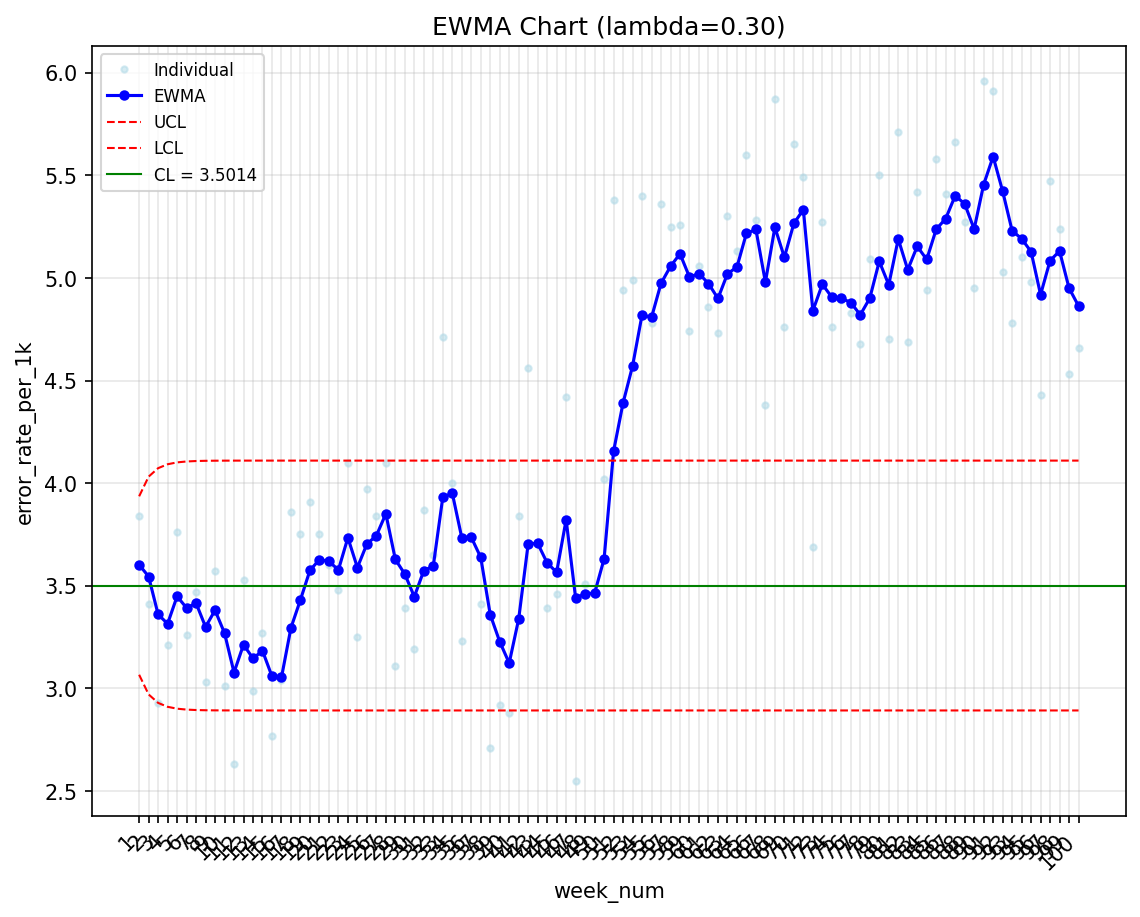

In [4]:
/* --------------------------------------------------------
   Fase II: overvåg hele 100-ugers serien mod de faste
   baseline-grænser. lambda=0,3 giver responsiv
   detektion egnet til patientsikkerheds-overvågning.
   -------------------------------------------------------- */
PROCEDURE macontrol data=work.icu_errors limits=work.icu_limits;
    ewmachart error_rate_per_1k * week_num /
        VÆGT    = 0.3
        sigmas    = 3
        readlimits
        outtable  = work.icu_table;
    MÆRKAT error_rate_per_1k =
          'Medicineringsfejl pr. 1.000 Administrationer';
    TITEL 'EWMA-diagram: ICU Medicineringsfejlrate (lambda=0,3)';
KØR;

---

In [5]:
/* --------------------------------------------------------
   Identificer hver uge, hvor EWMA overskrider baseline-
   grænserne, og rapporter hvornår diagrammet først signalerer.
   -------------------------------------------------------- */
data work.signals;
    SÆT work.icu_table;
    HVOR _EXLIM_ ne ' ' AND _EXLIM_ ne '0';
KØR;

PROCEDURE SQL;
    VÆLG count(*)        AS n_signals          MÆRKAT='Signaluger',
           MIN(week_num)    AS first_signal_week  MÆRKAT='Første Signaluge',
           MAX(_EWMA_)      AS peak_ewma format=6.3 MÆRKAT='Peak EWMA'
    FROM work.signals;
QUIT;

PROCEDURE PRINT data=work.signals(obs=8);
    VARIABEL week_num error_rate_per_1k _EWMA_ _UCLE_ _EXLIM_;
    TITEL 'Første Ude-af-Kontrol EWMA-signaler';
KØR;

                                     Fase I Kontrolgrænse-input (baseline uge 1-50)                                     

Signaluger   Første Signaluge  Peak EWMA
----------  -----------------  ---------
        50               51.0      5.591
                                          Første Ude-af-Kontrol EWMA-signaler                                           

  Obs  week_num    _EWMA_   _UCLE_  _EXLIM_
    1        51  4.155551  4.10998        1
    2        52  4.390886  4.10998        1
    3        53   4.57062  4.10998        1
    4        54  4.819434  4.10998        1
    5        55  4.807604  4.10998        1
    6        56  4.973323  4.10998        1
    7        57  5.056326  4.10998        1
    8        58  5.117428  4.10998        1

... 42 more observations (showing 8 of 50)




NOTE: DATA work.signals


NOTE: Read 100 rows from work.icu_table.
NOTE: Wrote work.signals (50 rows, 15 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC SQL 

NOTE: PROC SQL statement used.
NOTE: PROC PRINT data=work.signals

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---

### Fortolkning

Den to-fasede EWMA-analyse adskiller tydeligt almindelig uge-til-uge-variation fra den reelle procesændring ved eMAR-idriftsættelsen.

**Baseline (uge 1-50).** PROC MEANS rapporterer en gennemsnitlig baseline-fejlrate på **3,50 pr. 1.000 administrationer** (standardafvigelse 0,48), mod et gennemsnit efter migrering på **5,11** (standardafvigelse 0,44) — et vedvarende opadgående skift på ca. **1,6 fejl pr. 1.000**. Administrationsvolumen er sammenlignelig mellem de to faser (795 vs. 790 pr. uge), så ændringen afspejler fejl*raten*, ikke en ændring i arbejdsbyrden.

**Kontrolgrænser.** Grænser er fastsat udelukkende fra baseline: midterlinje **3,5014**, baseline-sigma **0,4829**. Med udjævningsvægt lambda = 0,3 og 3-sigma-grænser lander EWMA's øvre grænse på sin asymptotiske værdi på ca. **4,11**. Gennem hele uge 1-50 forbliver EWMA-statistikken inden for disse grænser — baseline giver **nul falske alarmer**, hvilket bekræfter, at diagrammet ikke er overfølsomt.

**Detektion.** Diagrammet signalerer ude-af-kontrol i **den allerførste uge efter idriftsættelse (uge 51)**, hvor EWMA når **4,156**, lige over grænsen på 4,11. Fra det tidspunkt stiger statistikken støt og forbliver over den øvre grænse gennem hele perioden efter migrering: **alle 50 uger efter migrering (51-100) signalerer**, og EWMA topper på **5,591** omkring uge 91. Responsiviteten ved lambda = 0,3 betyder, at forringelsen flages øjeblikkeligt frem for efter flere ugers akkumulering.

**Handling.** Et vedvarende EWMA-brud, der begynder ugen for en eMAR-udrulning, er stærk evidens for, at det nye system — ikke tilfældighed — drev stigningen. Patientsikkerhedsudvalget bør behandle uge 51 som ændringspunktet, revidere de eMAR-medicinordinations- og override-arbejdsgange, der blev introduceret den uge, og holde diagrammet kørende mod de oprindelige baseline-grænser, indtil EWMA vender tilbage under 4,11. Den eksporterede `icu_ewma_signals.csv` (50 signaluger) og `icu_ewma_table.csv` giver den dokumenterede SPC-evidenskæde til Joint Commissions kontinuerlige beredskabsgennemgang.

---

In [6]:
/* --------------------------------------------------------
   Eksporter EWMA-tabellen og signallisten til Joint
   Commission-dokumentation af kontinuerlig beredskab.
   -------------------------------------------------------- */
PROCEDURE EXPORT data=work.icu_table
    OUTFILE='icu_ewma_table.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EXPORT data=work.signals
    OUTFILE='icu_ewma_signals.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.icu_table outfile=icu_ewma_table.csv

NOTE: Exported 100 rows to icu_ewma_table.csv.
NOTE: PROC EXPORT data=work.signals outfile=icu_ewma_signals.csv

NOTE: Exported 50 rows to icu_ewma_signals.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>